# EDA Toan Dien — Du Lieu Van Ban Phap Luat Tieng Viet

> **Muc tieu:** Phan tich kham pha (Exploratory Data Analysis) cac file JSON chua du lieu bo luat Viet Nam, danh gia chat luong du lieu va chuan bi cho cac tac vu AI/NLP tiep theo.

---
**Nguon du lieu:** Thu muc `data/` va cac thu muc con  
**Cau truc moi moi file JSON:**
- `law_info`: Metadata bo luat (`law_id`, `law_name`, `publisher`, `document_number`, `issue_date`, `effective_date`, `status`, `executive_summary`)
- `clauses`: Mang cac dieu khoan (`id`, `position` (dict), `content`, `cross_references` (list), `tags` (list))

## 1.  Khởi Tạo & Cài Đặt Thư Viện

In [1]:
# --- Cài đặt thư viện (bỏ comment nếu chưa cài) ---
# !pip install pandas matplotlib seaborn wordcloud underthesea pyvi -q

# --- Import thư viện cốt lõi ---
import os
import glob
import json
import ast
import re
import warnings
from collections import Counter
from itertools import chain

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# --- NLP tiếng Việt ---
try:
    from underthesea import word_tokenize
    NLP_ENGINE = 'underthesea'
    print(' NLP engine: underthesea')
except ImportError:
    try:
        from pyvi import ViTokenizer
        NLP_ENGINE = 'pyvi'
        print(' NLP engine: pyvi')
    except ImportError:
        NLP_ENGINE = None
        print('  Không tìm thấy thư viện NLP — sẽ dùng tách từ đơn giản.')

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Cài đặt đồ họa ---
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
})
PALETTE = sns.color_palette('Set2')
sns.set_theme(style='whitegrid', palette='Set2')

print(' Tất cả thư viện đã được tải xong.')

 NLP engine: underthesea
 Tất cả thư viện đã được tải xong.


### 1.1 Stop-words Tiếng Việt

In [2]:
# Stop-words tiếng Việt — danh sách mở rộng cho văn bản pháp luật
STOPWORDS_VI = set([
    # Từ nối, giới từ, đại từ phổ biến
    'và','hoặc','của','cho','với','trong','theo','về','tại','từ','đến','là',
    'có','được','các','này','đó','thì','mà','khi','nếu','bởi','vì','do','như',
    'những','một','hai','ba','đã','sẽ','đang','không','vào','ra','lên','xuống',
    'trên','dưới','trước','sau','giữa','ngoài','bên','qua','lại','cũng','còn',
    'nên','phải','cần','thể','mọi','tất','cả','nhiều','ít','hơn','hết','rất',
    'đây','đấy','ấy','kia','đó','gì','ai','sao','bao','thế','nào','nào','hay',
    'nhưng','tuy','dù','song','vừa','vẫn','liền','ngay','sau','trước','mới',
    'chỉ','chính','đều','cùng','nhau','ta','tôi','họ','bạn','ông','bà',
    # Từ pháp lý có tần suất cao nhưng ít nghĩa phân biệt
    'điều','khoản','điểm','mục','chương','phần','luật','quy','định','hành',
    'việc','thực','hiện','số','ngày','tháng','năm','thứ','lần',
])

print(f' Tổng số stop-words: {len(STOPWORDS_VI)}')

 Tổng số stop-words: 110


---
## 2.  Đọc & Tiền Xử Lý Dữ Liệu

In [3]:
DATA_DIR = 'data'  # Doi sang duong dan thu muc data cua ban

# Quet de quy toan bo thu muc con
json_files = sorted(glob.glob(os.path.join(DATA_DIR, '**', '*.json'), recursive=True))
print(f'Tim thay {len(json_files)} file JSON:')
for f in json_files:
    print(f'   {f}')

Tim thay 17 file JSON:
   data\Group_2\44_2019_QH14_Luat_Phong_Chong_Tac_Hai_Ruou_Bia.json
   data\Group_2\49_VBHN_VPQH_2026_Luat_Duong_Bo.json
   data\Group_2\55_VBHN_VPQH_2026_Luat_TTATGT_Duong_Bo.json
   data\Group_2\63_VBHN_VPQH_2025_Luat_Xu_Ly_VPHC.json
   data\Group_2\Hien_Phap_2013.json
   data\Nhom_1\06_VBHN_VPQH_2026_Luat_Cu_tru.json
   data\Nhom_1\09_VBHN_VPQH_2026_Luat_Can_cuoc.json
   data\Nhom_1\121_VBHN_VPQH_2025_Luat_Hon_nhan_va_gia_dinh.json
   data\Nhom_1\125_VBHN_VPQH_2025_Bo_luat_Lao_dong.json
   data\Nhom_1\46_VBHN_VPQH_2025_Bo_Luat_To_tung_hinh_su.json
   data\Nhom_1\80_VBHN_VPQH_2025_Luat_Nghia_vu_quan_su.json
   data\Nhom_1\Luat_Ho_tich_2014.json
   data\Nhom_CL_HH\03_VBHN_VPQH_2025_Luat_Quy_Hoach.json
   data\Nhom_CL_HH\101_VBHN_VPQH_2025_Bo_Luat_Hang_Hai.json
   data\Nhom_CL_HH\105_2025_QH15_Luat_Giam_Dinh_Tu_Phap.json
   data\Nhom_CL_HH\135_VBHN_VPQH_2025_Bo_Luat_Hinh_Su.json
   data\Nhom_CL_HH\91_2015_QH13_Bo_Luat_Dan_Su.json


In [4]:
def parse_issue_date(date_str: str):
    """Chuyen dd/mm/yyyy hoac chuoi tu do thanh datetime."""
    if not date_str:
        return None
    for fmt in ('%d/%m/%Y', '%Y-%m-%d'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except Exception:
            pass
    # fallback: tim nam trong chuoi
    m = re.search(r'(20\d{2}|19\d{2})', str(date_str))
    return pd.to_datetime(m.group(1), format='%Y') if m else None

laws_rows    = []
clauses_rows = []
parse_errors = []

for fpath in json_files:
    try:
        with open(fpath, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        parse_errors.append({'file': fpath, 'error': str(e)})
        continue

    #  df_laws 
    li     = data.get('law_info', {})
    law_id = li.get('law_id', os.path.splitext(os.path.basename(fpath))[0])

    issue_dt = parse_issue_date(li.get('issue_date', ''))
    eff_dt   = parse_issue_date(li.get('effective_date', ''))

    laws_rows.append({
        'law_id'           : law_id,
        'law_name'         : li.get('law_name', ''),
        'publisher'        : li.get('publisher', ''),
        'document_number'  : li.get('document_number', ''),
        'issue_date'       : issue_dt,
        'effective_date'   : eff_dt,
        'issue_year'       : issue_dt.year if issue_dt else None,
        'status'           : li.get('status', ''),
        'executive_summary': li.get('executive_summary', ''),
        'source_file'      : os.path.relpath(fpath, DATA_DIR),
        'total_clauses'    : len(data.get('clauses', [])),
    })

    #  df_clauses 
    for clause in data.get('clauses', []):
        # position la dict that (khong con la chuoi)
        pos  = clause.get('position', {})
        if not isinstance(pos, dict):
            pos = {}

        # tags va cross_references la list that
        tags  = clause.get('tags', [])
        cross = clause.get('cross_references', [])
        if not isinstance(tags,  list): tags  = []
        if not isinstance(cross, list): cross = []

        clauses_rows.append({
            'clause_id'       : clause.get('id', ''),
            'law_id'          : law_id,
            'chapter'         : pos.get('chapter'),
            'article'         : pos.get('article'),
            'article_title'   : pos.get('article_title', ''),
            'clause_num'      : pos.get('clause'),
            'content'         : clause.get('content', ''),
            'tags'            : tags,
            'cross_references': cross,
            'n_tags'          : len(tags),
            'n_refs'          : len(cross),
        })

df_laws    = pd.DataFrame(laws_rows)
df_clauses = pd.DataFrame(clauses_rows)

# Chuyen kieu ngay
for col in ('issue_date', 'effective_date'):
    if col in df_laws.columns:
        df_laws[col] = pd.to_datetime(df_laws[col], errors='coerce')

# Them cot do luong van ban
df_clauses['char_count'] = df_clauses['content'].str.len().fillna(0).astype(int)
df_clauses['word_count'] = df_clauses['content'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)
df_clauses['is_empty'] = (
    df_clauses['content'].isna() |
    (df_clauses['content'].str.strip() == '')
)

print(f'Doc thanh cong {len(df_laws)} bo luat, {len(df_clauses):,} dieu khoan.')
if parse_errors:
    print(f'Loi khi parse: {parse_errors}')

Doc thanh cong 17 bo luat, 9,259 dieu khoan.


In [5]:
# Xem mau df_laws
print('=== df_laws (Metadata bo luat) ===')
display(df_laws.drop(columns=['executive_summary'], errors='ignore'))

print('\n=== df_clauses (mau 5 dong dau) ===')
display(df_clauses[['clause_id','law_id','chapter','article',
                     'content','word_count','char_count']].head())

=== df_laws (Metadata bo luat) ===


,law_id,law_name,publisher,document_number,issue_date,effective_date,issue_year,status,source_file,total_clauses
0,LPCTHRB_2019,"Luật Phòng, chống tác hại của rượu, bia 2019",Quốc hội,44/2019/QH14,2019-06-14,2020-01-01,2019,Đang có hiệu lực,Group_2\44_2019_QH14_Luat_Phong_Chong_Tac_Hai_Ruou_Bia.json,147
1,LDB_2024,Luật Đường bộ 2024 (Văn bản hợp nhất 49/VBHN-VPQH 2026),Văn phòng Quốc hội,49/VBHN-VPQH,2026-03-17,2025-01-01,2026,Đang có hiệu lực,Group_2\49_VBHN_VPQH_2026_Luat_Duong_Bo.json,392
2,LTTATGTDB_2024,"Luật Trật tự, an toàn giao thông đường bộ 2024 (Văn bản hợp nhất 55/VBHN-VPQH 2026)",Văn phòng Quốc hội,55/VBHN-VPQH,2026-03-23,2025-01-01,2026,Đang có hiệu lực,Group_2\55_VBHN_VPQH_2026_Luat_TTATGT_Duong_Bo.json,446
3,LXLVPHC_2012,Luật Xử lý vi phạm hành chính 2012 (Văn bản hợp nhất 63/VBHN-VPQH 2025),Văn phòng Quốc hội,63/VBHN-VPQH,2025-08-15,2013-07-01,2025,Đang có hiệu lực,Group_2\63_VBHN_VPQH_2025_Luat_Xu_Ly_VPHC.json,429
4,HP_2013,Hiến pháp nước Cộng hòa xã hội chủ nghĩa Việt Nam năm 2013,Quốc hội,Khongso,2013-11-28,2014-01-01,2013,Đang có hiệu lực,Group_2\Hien_Phap_2013.json,295
5,LCT_VBHN,Luật Cư trú 2020 (Văn bản hợp nhất 06/VBHN-VPQH),Văn phòng Quốc hội,06/VBHN-VPQH,2026-02-05,2021-07-01,2026,Đang có hiệu lực,Nhom_1\06_VBHN_VPQH_2026_Luat_Cu_tru.json,153
6,LCC_VBHN,Luật Căn cước 2023 (Văn bản hợp nhất 09/VBHN-VPQH),Văn phòng Quốc hội,09/VBHN-VPQH,2026-02-05,2024-07-01,2026,Đang có hiệu lực,Nhom_1\09_VBHN_VPQH_2026_Luat_Can_cuoc.json,227
7,LHNGD_VBHN,Luật Hôn nhân và gia đình 2014 (Văn bản hợp nhất 121/VBHN-VPQH),Văn phòng Quốc hội,121/VBHN-VPQH,2025-08-27,2015-01-01,2025,Đang có hiệu lực,Nhom_1\121_VBHN_VPQH_2025_Luat_Hon_nhan_va_gia_dinh.json,319
8,BLLD_VBHN,Bộ luật Lao động 2019 (Văn bản hợp nhất 125/VBHN-VPQH),Văn phòng Quốc hội,125/VBHN-VPQH,2025-08-27,2021-01-01,2025,Đang có hiệu lực,Nhom_1\125_VBHN_VPQH_2025_Bo_luat_Lao_dong.json,648
9,BLTTHS_VBHN,Bộ luật Tố tụng hình sự 2015 (Văn bản hợp nhất 46/VBHN-VPQH),Văn phòng Quốc hội,46/VBHN-VPQH,2025-02-28,2016-07-01,2025,Đang có hiệu lực,Nhom_1\46_VBHN_VPQH_2025_Bo_Luat_To_tung_hinh_su.json,1335



=== df_clauses (mau 5 dong dau) ===


,clause_id,law_id,chapter,article,content,word_count,char_count
0,LPCTHRB_2019_D1,LPCTHRB_2019,0,1,"Luật này quy định biện pháp giảm mức tiêu thụ rượu, bia; biện pháp quản lý việc cung cấp rượu, bia; biện pháp giảm t...",65,309
1,LPCTHRB_2019_D2_K0,LPCTHRB_2019,0,2,"Trong Luật này, các từ ngữ dưới đây được hiểu như sau:",12,54
2,LPCTHRB_2019_D2_K1,LPCTHRB_2019,0,2,"1. Rượu là đồ uống có cồn thực phẩm, được sản xuất từ quá trình lên men từ một hoặc hỗn hợp của các loại nguyên liệu...",53,230
3,LPCTHRB_2019_D2_K2,LPCTHRB_2019,0,2,"2. Bia là đồ uống có cồn thực phẩm, được sản xuất từ quá trình lên men từ hỗn hợp của các loại nguyên liệu chủ yếu g...",41,187
4,LPCTHRB_2019_D2_K3,LPCTHRB_2019,0,2,3. Cồn thực phẩm là hợp chất hữu cơ có công thức phân tử là C2H5OH và có tên khoa học là ethanol đã được loại bỏ tạp...,54,237


---
## 3.  EDA Trên Metadata (Siêu Dữ Liệu)

In [6]:
# --- Tong quan nhanh ---
total_laws    = len(df_laws)
total_clauses = len(df_clauses)
avg_clauses   = df_laws['total_clauses'].mean()

yr_valid = df_laws['issue_year'].dropna()
year_range = f"{int(yr_valid.min())} – {int(yr_valid.max())}" if len(yr_valid) else 'N/A'

summary = pd.DataFrame({
    'Chi so'  : ['Tong so bo luat','Tong so dieu khoan','TB dieu khoan/luat','Khoang thoi gian'],
    'Gia tri' : [total_laws, f'{total_clauses:,}', f'{avg_clauses:.0f}', year_range],
})
print('TONG QUAN TAP DU LIEU')
display(summary.set_index('Chi so'))

TONG QUAN TAP DU LIEU


,Gia tri
Chi so,
Tong so bo luat,17
Tong so dieu khoan,"9,259"
TB dieu khoan/luat,545
Khoang thoi gian,2013 – 2026


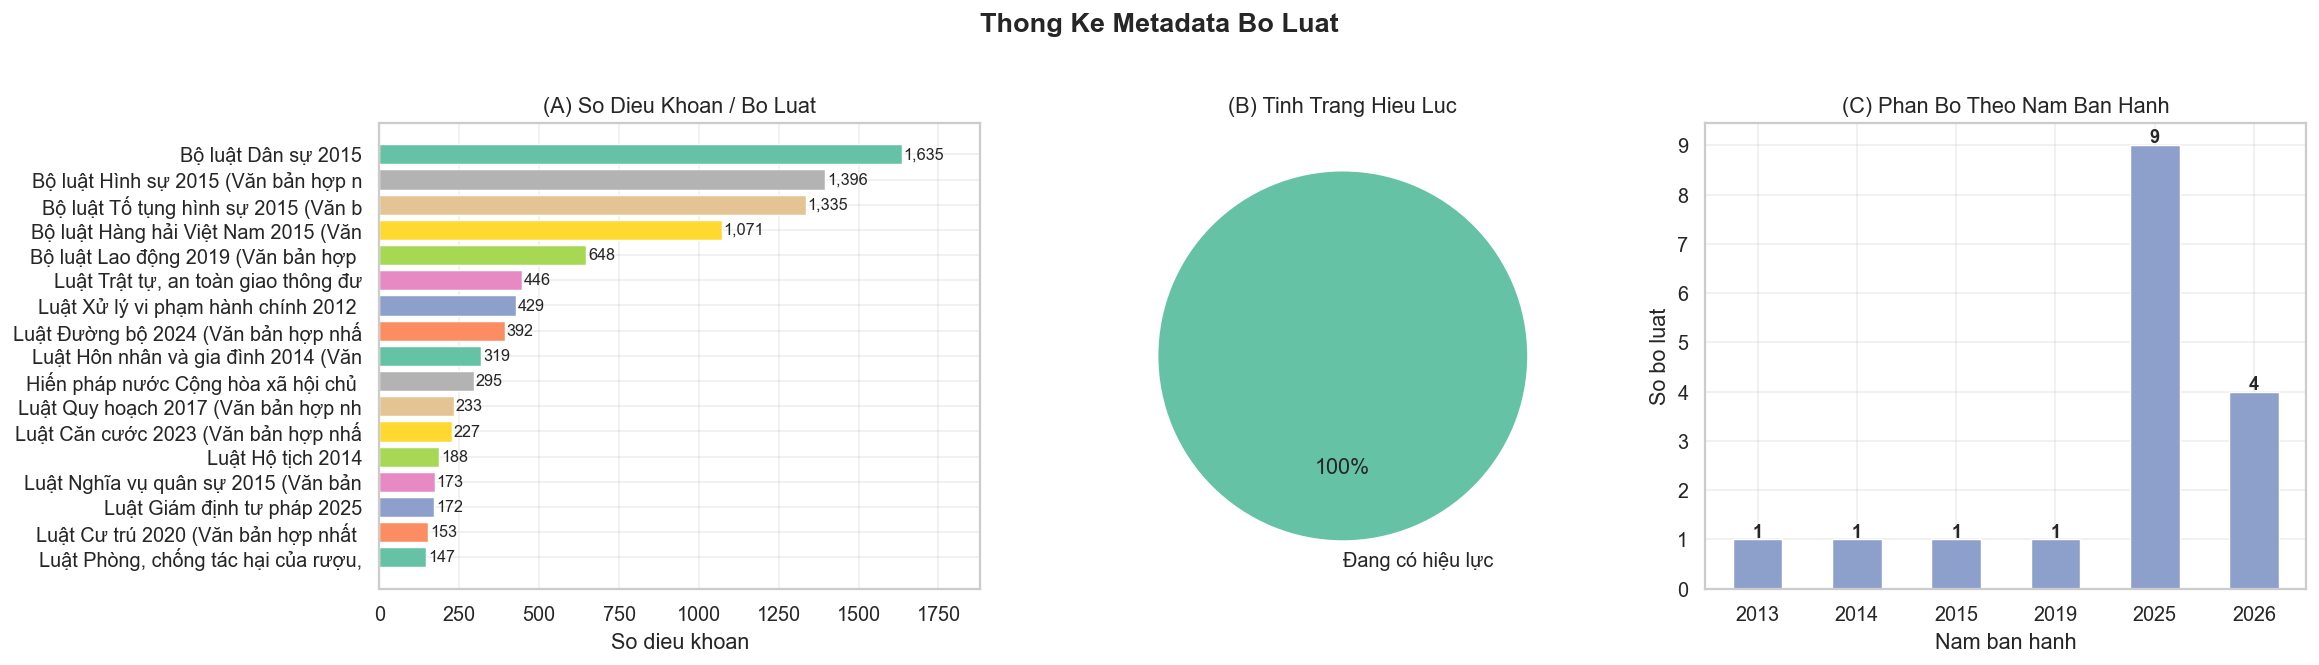

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Thong Ke Metadata Bo Luat', fontsize=15, fontweight='bold', y=1.02)

# --- (A) So dieu khoan theo bo luat ---
ax = axes[0]
sorted_laws = df_laws.sort_values('total_clauses', ascending=True)
bars = ax.barh(
    [l[:35] for l in sorted_laws['law_name']],
    sorted_laws['total_clauses'],
    color=PALETTE[:len(df_laws)],
    edgecolor='white', linewidth=0.8
)
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
ax.set_xlabel('So dieu khoan')
ax.set_title('(A) So Dieu Khoan / Bo Luat')
ax.margins(x=0.15)

# --- (B) Tinh trang hieu luc ---
ax = axes[1]
status_counts = df_laws['status'].value_counts()
ax.pie(
    status_counts.values, labels=status_counts.index,
    autopct='%1.0f%%', colors=PALETTE, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('(B) Tinh Trang Hieu Luc')

# --- (C) Timeline theo nam ban hanh ---
ax = axes[2]
year_counts = df_laws.dropna(subset=['issue_year']) \
                     .groupby('issue_year')['law_id'].count().reset_index()
year_counts.columns = ['Nam', 'So bo luat']
ax.bar(year_counts['Nam'].astype(int).astype(str), year_counts['So bo luat'],
       color=PALETTE[2], edgecolor='white', linewidth=0.8, width=0.5)
for _, row in year_counts.iterrows():
    ax.text(str(int(row['Nam'])), row['So bo luat'] + 0.05,
            str(row['So bo luat']), ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Nam ban hanh')
ax.set_ylabel('So bo luat')
ax.set_title('(C) Phan Bo Theo Nam Ban Hanh')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
# plt.savefig('metadata_overview.png', bbox_inches='tight')
plt.show()

In [8]:
print('CHI TIET TUNG BO LUAT')
detail = df_laws[['law_id','law_name','publisher','document_number',
                   'issue_date','effective_date','status','total_clauses']].copy()
detail['issue_date']     = detail['issue_date'].dt.strftime('%d/%m/%Y')
detail['effective_date'] = detail['effective_date'].dt.strftime('%d/%m/%Y')
detail.columns = ['Ma luat','Ten bo luat','Co quan ban hanh','So hieu van ban',
                  'Ngay ban hanh','Hieu luc tu','Tinh trang','So dieu khoan']
display(detail)

CHI TIET TUNG BO LUAT


,Ma luat,Ten bo luat,Co quan ban hanh,So hieu van ban,Ngay ban hanh,Hieu luc tu,Tinh trang,So dieu khoan
0,LPCTHRB_2019,"Luật Phòng, chống tác hại của rượu, bia 2019",Quốc hội,44/2019/QH14,14/06/2019,01/01/2020,Đang có hiệu lực,147
1,LDB_2024,Luật Đường bộ 2024 (Văn bản hợp nhất 49/VBHN-VPQH 2026),Văn phòng Quốc hội,49/VBHN-VPQH,17/03/2026,01/01/2025,Đang có hiệu lực,392
2,LTTATGTDB_2024,"Luật Trật tự, an toàn giao thông đường bộ 2024 (Văn bản hợp nhất 55/VBHN-VPQH 2026)",Văn phòng Quốc hội,55/VBHN-VPQH,23/03/2026,01/01/2025,Đang có hiệu lực,446
3,LXLVPHC_2012,Luật Xử lý vi phạm hành chính 2012 (Văn bản hợp nhất 63/VBHN-VPQH 2025),Văn phòng Quốc hội,63/VBHN-VPQH,15/08/2025,01/07/2013,Đang có hiệu lực,429
4,HP_2013,Hiến pháp nước Cộng hòa xã hội chủ nghĩa Việt Nam năm 2013,Quốc hội,Khongso,28/11/2013,01/01/2014,Đang có hiệu lực,295
5,LCT_VBHN,Luật Cư trú 2020 (Văn bản hợp nhất 06/VBHN-VPQH),Văn phòng Quốc hội,06/VBHN-VPQH,05/02/2026,01/07/2021,Đang có hiệu lực,153
6,LCC_VBHN,Luật Căn cước 2023 (Văn bản hợp nhất 09/VBHN-VPQH),Văn phòng Quốc hội,09/VBHN-VPQH,05/02/2026,01/07/2024,Đang có hiệu lực,227
7,LHNGD_VBHN,Luật Hôn nhân và gia đình 2014 (Văn bản hợp nhất 121/VBHN-VPQH),Văn phòng Quốc hội,121/VBHN-VPQH,27/08/2025,01/01/2015,Đang có hiệu lực,319
8,BLLD_VBHN,Bộ luật Lao động 2019 (Văn bản hợp nhất 125/VBHN-VPQH),Văn phòng Quốc hội,125/VBHN-VPQH,27/08/2025,01/01/2021,Đang có hiệu lực,648
9,BLTTHS_VBHN,Bộ luật Tố tụng hình sự 2015 (Văn bản hợp nhất 46/VBHN-VPQH),Văn phòng Quốc hội,46/VBHN-VPQH,28/02/2025,01/07/2016,Đang có hiệu lực,1335


---
## 4.  EDA Trên Nội Dung Văn Bản (Text Analysis)

### 4.1 Phân Phối Độ Dài Văn Bản

In [9]:
# Thống kê mô tả độ dài
stats = df_clauses.groupby('law_id')[['word_count','char_count']].describe().round(1)
print(' THỐNG KÊ ĐỘ DÀI ĐIỀU KHOẢN THEO BỘ LUẬT')
display(stats)

 THỐNG KÊ ĐỘ DÀI ĐIỀU KHOẢN THEO BỘ LUẬT


word_count                                               \
                    count  mean   std   min   25%   50%    75%     max   
law_id                                                                   
BLDS_2015         1635.00 44.60 34.00  2.00 22.00 36.00  57.00  289.00   
BLHH_VBHN         1071.00 51.20 38.90  3.00 27.00 42.00  63.00  411.00   
BLHS_VBHN         1396.00 76.90 74.80  2.00 34.00 58.00  92.00  885.00   
BLLD_VBHN          648.00 58.10 62.90  2.00 26.00 43.00  70.20 1050.00   
BLTTHS_VBHN       1335.00 77.00 67.30  2.00 37.00 59.00  93.00  604.00   
HP_2013            295.00 42.90 26.90  5.00 24.00 37.00  54.50  175.00   
LCC_VBHN           227.00 53.70 49.90  2.00 22.50 42.00  66.00  366.00   
LCT_VBHN           153.00 57.00 44.30  7.00 25.00 44.00  73.00  275.00   
LDB_2024           392.00 78.70 68.30  4.00 37.80 55.00  95.00  447.00   
LGDTP_2025         172.00 82.20 67.90  8.00 42.80 62.00 106.00  428.00   
LHNGD_VBHN         319.00 53.70 32.10  8.00 32.00 46.00  67.00  239.00   
LHT_2014           188.00 56.10 33.90 11.00 31.00 48.00  73.50  217.00   
LNVQS_VBHN         173.00 51.80 54.30  7.00 23.00 36.00  58.00  370.00   
LPCTHRB_2019       147.00 40.10 28.60  5.00 20.00 32.00  51.00  168.00   
LQH_VBHN           233.00 57.10 63.00  2.00 20.00 37.00  69.00  400.00   
LTTATGTDB_2024     446.00 78.70 79.50  4.00 35.20 53.00  92.00  785.00   
LXLVPHC_2012       429.00 87.20 85.80  3.00 36.00 60.00 113.00  838.00   

               char_count                                                   
                    count   mean    std   min    25%    50%    75%     max  
law_id                                                                      
BLDS_2015         1635.00 200.10 151.30  7.00 100.00 164.00 254.00 1288.00  
BLHH_VBHN         1071.00 233.00 176.40 13.00 123.00 189.00 289.00 1907.00  
BLHS_VBHN         1396.00 352.90 349.40  8.00 153.00 260.00 414.00 4111.00  
BLLD_VBHN          648.00 264.10 280.30  8.00 118.00 195.00 321.20 4510.00  
BLTTHS_VBHN       1335.00 345.10 305.80  7.00 163.00 263.00 418.50 2689.00  
HP_2013            295.00 194.40 124.70 22.00 106.50 167.00 245.50  821.00  
LCC_VBHN           227.00 237.50 222.70  8.00 100.00 182.00 296.50 1635.00  
LCT_VBHN           153.00 249.00 192.90 32.00 111.00 197.00 322.00 1207.00  
LDB_2024           392.00 356.00 312.20 19.00 167.00 248.00 423.50 2065.00  
LGDTP_2025         172.00 375.30 306.60 37.00 190.80 290.00 493.80 1889.00  
LHNGD_VBHN         319.00 239.00 142.50 37.00 138.00 210.00 298.00 1053.00  
LHT_2014           188.00 244.50 148.80 49.00 134.00 213.00 318.50  964.00  
LNVQS_VBHN         173.00 230.10 241.10 28.00 101.00 160.00 267.00 1648.00  
LPCTHRB_2019       147.00 184.20 131.60 14.00  94.00 149.00 232.50  765.00  
LQH_VBHN           233.00 262.10 290.80  9.00  93.00 175.00 317.00 1814.00  
LTTATGTDB_2024     446.00 354.10 348.60 20.00 162.00 239.00 416.00 3252.00  
LXLVPHC_2012       429.00 396.20 395.40 12.00 163.00 263.00 511.00 3880.00

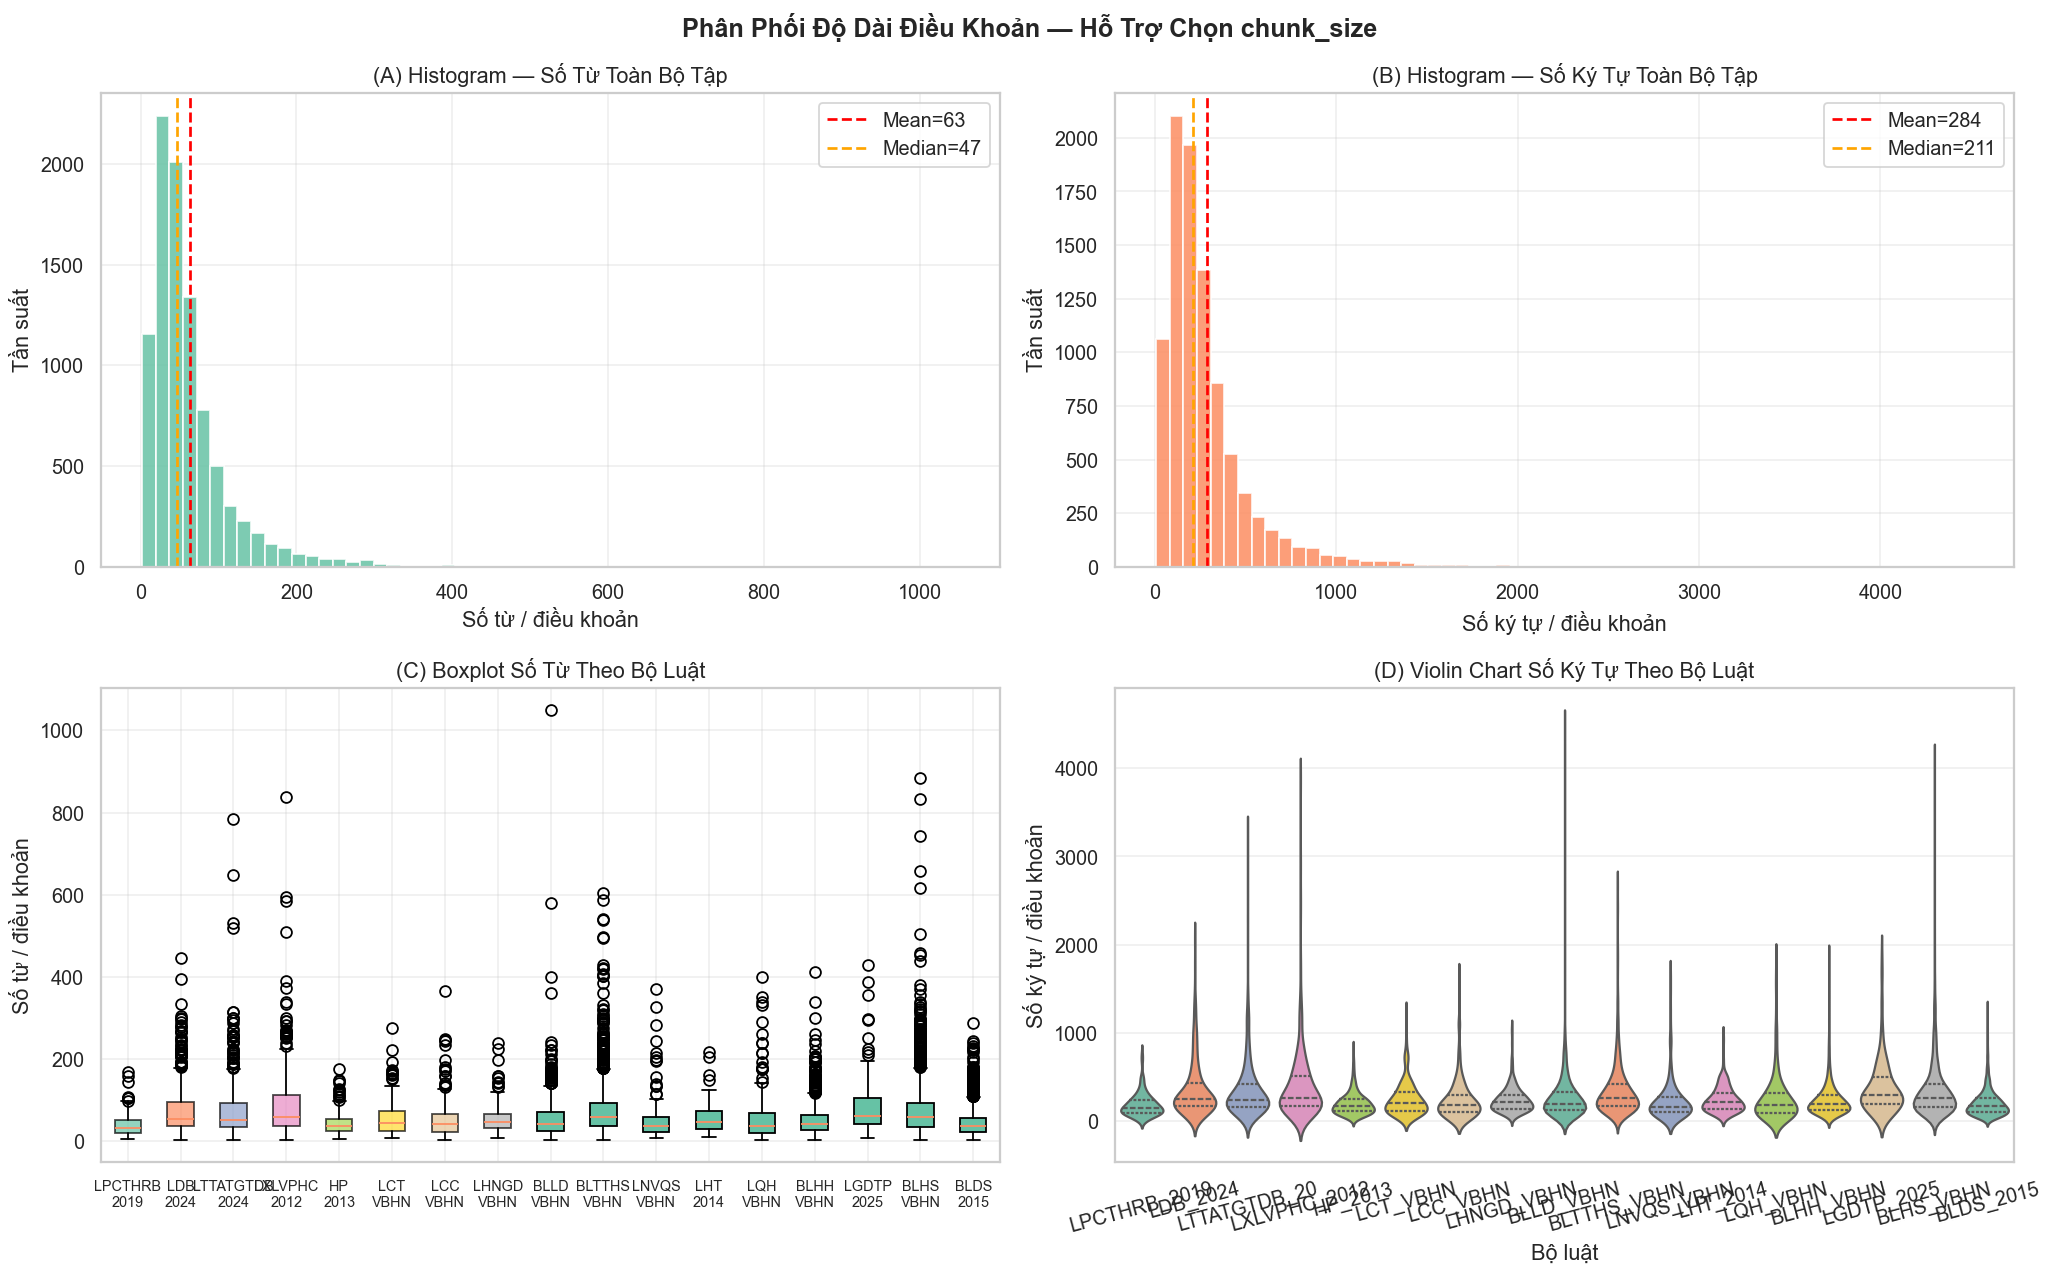

 Đã lưu: text_length_distribution.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Phân Phối Độ Dài Điều Khoản — Hỗ Trợ Chọn chunk_size', fontsize=14, fontweight='bold')

law_ids = df_clauses['law_id'].unique()

# --- (A) Histogram word_count toàn bộ ---
ax = axes[0, 0]
ax.hist(df_clauses['word_count'], bins=60, color=PALETTE[0], edgecolor='white', alpha=0.85)
median_wc = df_clauses['word_count'].median()
mean_wc   = df_clauses['word_count'].mean()
ax.axvline(mean_wc, color='red', linestyle='--', label=f'Mean={mean_wc:.0f}')
ax.axvline(median_wc, color='orange', linestyle='--', label=f'Median={median_wc:.0f}')
ax.set_xlabel('Số từ / điều khoản')
ax.set_ylabel('Tần suất')
ax.set_title('(A) Histogram — Số Từ Toàn Bộ Tập')
ax.legend()

# --- (B) Histogram char_count toàn bộ ---
ax = axes[0, 1]
ax.hist(df_clauses['char_count'], bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85)
median_cc = df_clauses['char_count'].median()
mean_cc   = df_clauses['char_count'].mean()
ax.axvline(mean_cc, color='red', linestyle='--', label=f'Mean={mean_cc:.0f}')
ax.axvline(median_cc, color='orange', linestyle='--', label=f'Median={median_cc:.0f}')
ax.set_xlabel('Số ký tự / điều khoản')
ax.set_ylabel('Tần suất')
ax.set_title('(B) Histogram — Số Ký Tự Toàn Bộ Tập')
ax.legend()

# --- (C) Boxplot word_count theo bộ luật ---
ax = axes[1, 0]
law_name_map = df_laws.set_index('law_id')['law_name'].to_dict()
plot_data = [
    df_clauses[df_clauses['law_id'] == lid]['word_count'].values
    for lid in law_ids
]
bp = ax.boxplot(plot_data, patch_artist=True, vert=True, notch=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(law_ids)+1))
ax.set_xticklabels([lid.replace('_', '\n') for lid in law_ids], fontsize=8)
ax.set_ylabel('Số từ / điều khoản')
ax.set_title('(C) Boxplot Số Từ Theo Bộ Luật')

# --- (D) Violin char_count theo bộ luật ---
ax = axes[1, 1]
df_plot = df_clauses[['law_id','char_count']].copy()
df_plot['law_short'] = df_plot['law_id'].apply(lambda x: x[:12])
sns.violinplot(data=df_plot, x='law_short', y='char_count',
               palette='Set2', inner='quartile', ax=ax)
ax.set_xlabel('Bộ luật')
ax.set_ylabel('Số ký tự / điều khoản')
ax.set_title('(D) Violin Chart Số Ký Tự Theo Bộ Luật')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
# plt.savefig('text_length_distribution.png', bbox_inches='tight')
plt.show()
print(' Đã lưu: text_length_distribution.png')

### 4.2 Phân Tích Outliers — Điều Khoản Cực Ngắn & Cực Dài

In [11]:
DISPLAY_COLS = ['clause_id','law_id','article_title','word_count','char_count','content']

print('TOP 5 DIEU KHOAN NGAN NHAT (theo so tu)')
display(df_clauses.nsmallest(5, 'word_count')[DISPLAY_COLS])

print('\nTOP 5 DIEU KHOAN DAI NHAT (theo so tu)')
display(df_clauses.nlargest(5, 'word_count')[DISPLAY_COLS])

TOP 5 DIEU KHOAN NGAN NHAT (theo so tu)


,clause_id,law_id,article_title,word_count,char_count,content
1918,LCC_VBHN_D9_K5,LCC_VBHN,Thông tin trong Cơ sở dữ liệu quốc gia về dân cư,2,10,Giới tính.
1919,LCC_VBHN_D9_K6,LCC_VBHN,Thông tin trong Cơ sở dữ liệu quốc gia về dân cư,2,9,Nơi sinh.
1921,LCC_VBHN_D9_K8,LCC_VBHN,Thông tin trong Cơ sở dữ liệu quốc gia về dân cư,2,9,Quê quán.
1922,LCC_VBHN_D9_K9,LCC_VBHN,Thông tin trong Cơ sở dữ liệu quốc gia về dân cư,2,8,Dân tộc.
1923,LCC_VBHN_D9_K10,LCC_VBHN,Thông tin trong Cơ sở dữ liệu quốc gia về dân cư,2,9,Tôn giáo.



TOP 5 DIEU KHOAN DAI NHAT (theo so tu)


,clause_id,law_id,article_title,word_count,char_count,content
3051,BLLD_VBHN_D219_K1,BLLD_VBHN,"Sửa đổi, bổ sung một số điều của các luật có liên quan đến lao động",1050,4510,"Sửa đổi, bổ sung một số điều của Luật Bảo hiểm xã hội số 58/2014/QH13 đã được sửa đổi, bổ sung theo Luật số 84/2015/..."
6917,BLHS_VBHN_D235_K1,BLHS_VBHN,Tội gây ô nhiễm môi trường,885,4111,"Người nào thực hiện một trong các hành vi sau đây, thì bị phạt tiền từ 100.000.000 đồng đến 1.000.000.000 đồng hoặc ..."
1350,LXLVPHC_2012_D126_K4,LXLVPHC_2012,"Xử lý tang vật, phương tiện, giấy phép, chứng chỉ hành nghề bị tạm giữ theo thủ tục hành chính",838,3880,"4.[211] Đối với tang vật, phương tiện vi phạm hành chính bị tạm giữ theo quy định tại điểm a và điểm b khoản 1 Điều ..."
6902,BLHS_VBHN_D232_K1,BLHS_VBHN,"Tội vi phạm quy định về khai thác, bảo vệ rừng và lâm sản",832,3877,"Người nào thực hiện một trong các hành vi sau đây, nếu không thuộc trường hợp quy định tại Điều 243 của Bộ luật này,..."
818,LTTATGTDB_2024_D57_K1,LTTATGTDB_2024,Giấy phép lái xe,785,3252,1. Giấy phép lái xe bao gồm các hạng sau đây:\n\na) Hạng A1 cấp cho người lái xe mô tô hai bánh có dung tích xi-lanh...


In [12]:
# Percentile analysis — phục vụ chọn chunk_size
percentiles = [10, 25, 50, 75, 90, 95, 99]
print(' PHÂN VỊ ĐỘ DÀI ĐIỀU KHOẢN (hỗ trợ quyết định chunk_size):')
pct_df = pd.DataFrame({
    'Percentile': [f'P{p}' for p in percentiles],
    'Số từ'     : [int(np.percentile(df_clauses['word_count'], p)) for p in percentiles],
    'Số ký tự'  : [int(np.percentile(df_clauses['char_count'], p)) for p in percentiles],
})
display(pct_df.set_index('Percentile'))

 PHÂN VỊ ĐỘ DÀI ĐIỀU KHOẢN (hỗ trợ quyết định chunk_size):


,Số từ,Số ký tự
Percentile,,
P10,17,78
P25,28,127
P50,47,211
P75,75,339
P90,124,562
P95,171,774
P99,293,1339


### 4.3 Kiểm Tra Dữ Liệu Rỗng (Missing Values)

In [13]:
missing = df_clauses.isnull().sum()
empty_str = (df_clauses.select_dtypes('object') == '').sum()
empty_content = df_clauses['is_empty'].sum()

print('BAO CAO DU LIEU THIEU (df_clauses):')
miss_report = pd.DataFrame({
    'Null / NaN'  : missing,
    'Chuoi rong'  : empty_str.reindex(missing.index, fill_value=0),
}).assign(**{
    'Tong thieu': lambda df: df.sum(axis=1),
    'Ty le (%)' : lambda df: (df['Tong thieu'] / len(df_clauses) * 100).round(2)
})
display(miss_report.sort_values('Tong thieu', ascending=False))

print(f'\nDieu khoan co content rong/null: {empty_content} / {len(df_clauses)} ({empty_content/len(df_clauses)*100:.2f}%)')

BAO CAO DU LIEU THIEU (df_clauses):


,Null / NaN,Chuoi rong,Tong thieu,Ty le (%)
clause_num,395,0,395,4.27
article_title,0,295,295,3.19
law_id,0,0,0,0.00
clause_id,0,0,0,0.00
article,0,0,0,0.00
chapter,0,0,0,0.00
content,0,0,0,0.00
tags,0,0,0,0.00
cross_references,0,0,0,0.00
n_tags,0,0,0,0.00



Dieu khoan co content rong/null: 0 / 9259 (0.00%)


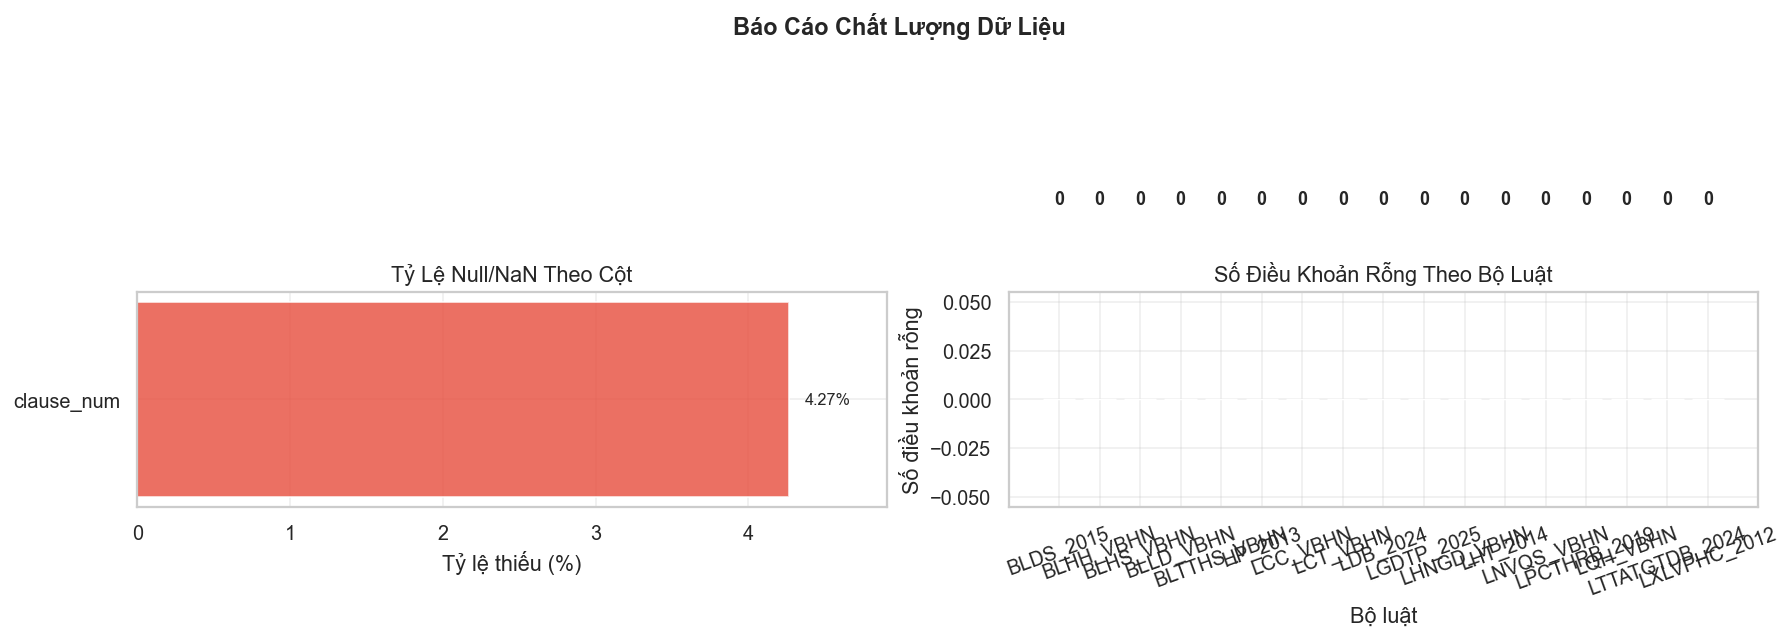

 Đã lưu: data_quality.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Báo Cáo Chất Lượng Dữ Liệu', fontsize=13, fontweight='bold')

# --- Missing heatmap ---
ax = axes[0]
miss_pct = (df_clauses.isnull().mean() * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0] if miss_pct.max() > 0 else miss_pct.head(6)
bars = ax.barh(miss_pct.index, miss_pct.values, color='#e74c3c', alpha=0.8)
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=9)
ax.set_xlabel('Tỷ lệ thiếu (%)')
ax.set_title('Tỷ Lệ Null/NaN Theo Cột')
ax.margins(x=0.15)

# --- Empty content by law ---
ax = axes[1]
empty_by_law = df_clauses.groupby('law_id')['is_empty'].sum().sort_values(ascending=False)
bars = ax.bar(empty_by_law.index, empty_by_law.values,
              color=PALETTE[3], edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Bộ luật')
ax.set_ylabel('Số điều khoản rỗng')
ax.set_title('Số Điều Khoản Rỗng Theo Bộ Luật')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
# plt.savefig('data_quality.png', bbox_inches='tight')
plt.show()
print(' Đã lưu: data_quality.png')

### 4.4 Kiểm Tra Độ Nhiễu — Ký Tự Đặc Biệt & HTML

In [15]:
NOISE_PATTERNS = {
    'HTML tags'           : re.compile(r'<[a-zA-Z][^>]*>|</[a-zA-Z]+>'),
    'HTML entities'       : re.compile(r'&[a-zA-Z]{2,6};|&#\d+;'),
    'Ky tu khong in duoc' : re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]'),
    'Nhieu khoang trang'  : re.compile(r' {3,}'),
    'Ky tu dac biet la'   : re.compile(r'[\u2000-\u206f\ufff0-\uffff]'),
    'Dong moi thua'       : re.compile(r'\n{3,}'),
    'Ky tu lap bat thuong': re.compile(r'(.)\1{5,}'),
}

def scan_noise(text: str) -> dict:
    results = {}
    for name, pat in NOISE_PATTERNS.items():
        hits = pat.findall(str(text))
        results[name] = len(hits)
    return results

noise_cols = list(NOISE_PATTERNS.keys())
noise_df = df_clauses['content'].apply(scan_noise).apply(pd.Series)
for col in noise_cols:
    df_clauses[f'noise_{col}'] = noise_df[col]

print('BAO CAO DO NHIEU TOAN TAP DU LIEU:')
noise_summary = pd.DataFrame({
    'Loai nhieu'                 : noise_cols,
    'Tong lan xuat hien'         : [noise_df[c].sum() for c in noise_cols],
    'So dieu khoan bi anh huong' : [(noise_df[c] > 0).sum() for c in noise_cols],
    'Ty le anh huong (%)'        : [(noise_df[c] > 0).mean() * 100 for c in noise_cols],
})
noise_summary['Ty le anh huong (%)'] = noise_summary['Ty le anh huong (%)'].round(3)
display(noise_summary.set_index('Loai nhieu'))

BAO CAO DO NHIEU TOAN TAP DU LIEU:


,Tong lan xuat hien,So dieu khoan bi anh huong,Ty le anh huong (%)
Loai nhieu,,,
HTML tags,0,0,0.00
HTML entities,0,0,0.00
Ky tu khong in duoc,0,0,0.00
Nhieu khoang trang,0,0,0.00
Ky tu dac biet la,49,12,0.13
Dong moi thua,4,4,0.04
Ky tu lap bat thuong,0,0,0.00


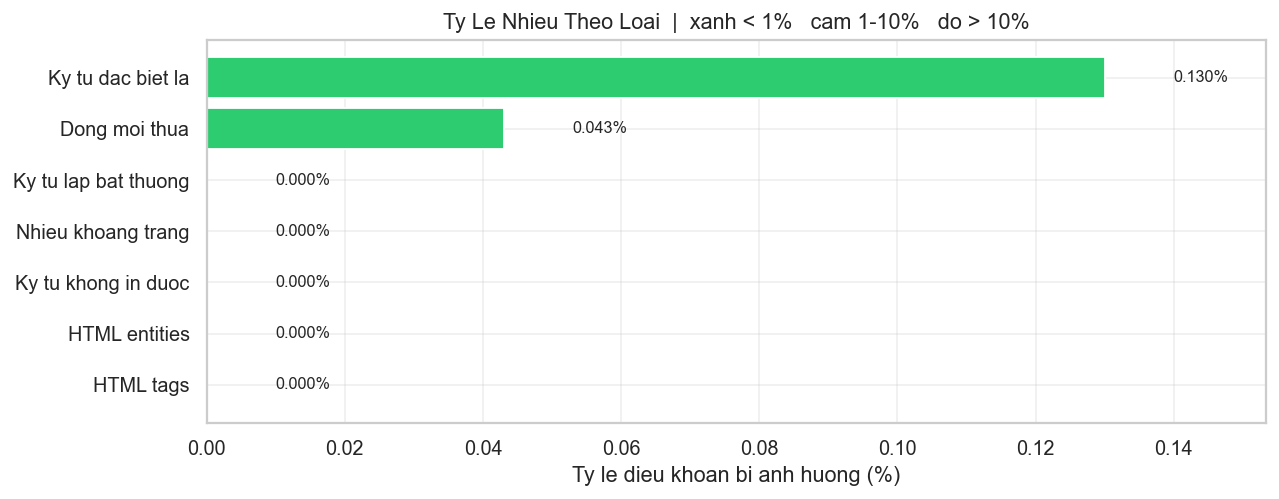

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
impact = noise_summary.set_index('Loai nhieu')['Ty le anh huong (%)'].sort_values(ascending=True)
colors = ['#2ecc71' if v < 1 else '#f39c12' if v < 10 else '#e74c3c' for v in impact.values]
bars = ax.barh(impact.index, impact.values, color=colors, edgecolor='white')
for bar in bars:
    w = bar.get_width()
    label = f'{w:.3f}%' if w < 1 else f'{w:.1f}%'
    ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)
ax.set_xlabel('Ty le dieu khoan bi anh huong (%)')
ax.set_title('Ty Le Nhieu Theo Loai  |  xanh < 1%   cam 1-10%   do > 10%')
ax.margins(x=0.18)
plt.tight_layout()
# plt.savefig('noise_analysis.png', bbox_inches='tight')
plt.show()

---
## 5.  Phân Tích NLP — Tần Suất Từ & N-grams

### 5.1 Tách Từ (Tokenization)

In [18]:
def tokenize_vi(text: str) -> list[str]:
    """Tách từ tiếng Việt, chuyển thường, loại bỏ stop-words."""
    if not text or not isinstance(text, str):
        return []
    # Loại bỏ số, ký tự đặc biệt
    text = re.sub(r'[\d\n\r\t]+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    text = text.lower().strip()

    if NLP_ENGINE == 'underthesea':
        tokens = word_tokenize(text, format='text').split()
    elif NLP_ENGINE == 'pyvi':
        tokens = ViTokenizer.tokenize(text).split()
    else:
        tokens = text.split()

    return [t.replace('_', ' ') for t in tokens
            if t not in STOPWORDS_VI and len(t) > 1]

print('⏳ Đang tách từ toàn bộ điều khoản... (có thể mất vài phút)')
df_sample = df_clauses.copy()
df_sample['tokens'] = df_sample['content'].apply(tokenize_vi)

all_tokens = list(chain.from_iterable(df_sample['tokens']))
print(f' Tách từ xong. Tổng số token: {len(all_tokens):,}')

⏳ Đang tách từ toàn bộ điều khoản... (có thể mất vài phút)
 Tách từ xong. Tổng số token: 257,683


### 5.2 WordCloud

 Số từ duy nhất: 5,319


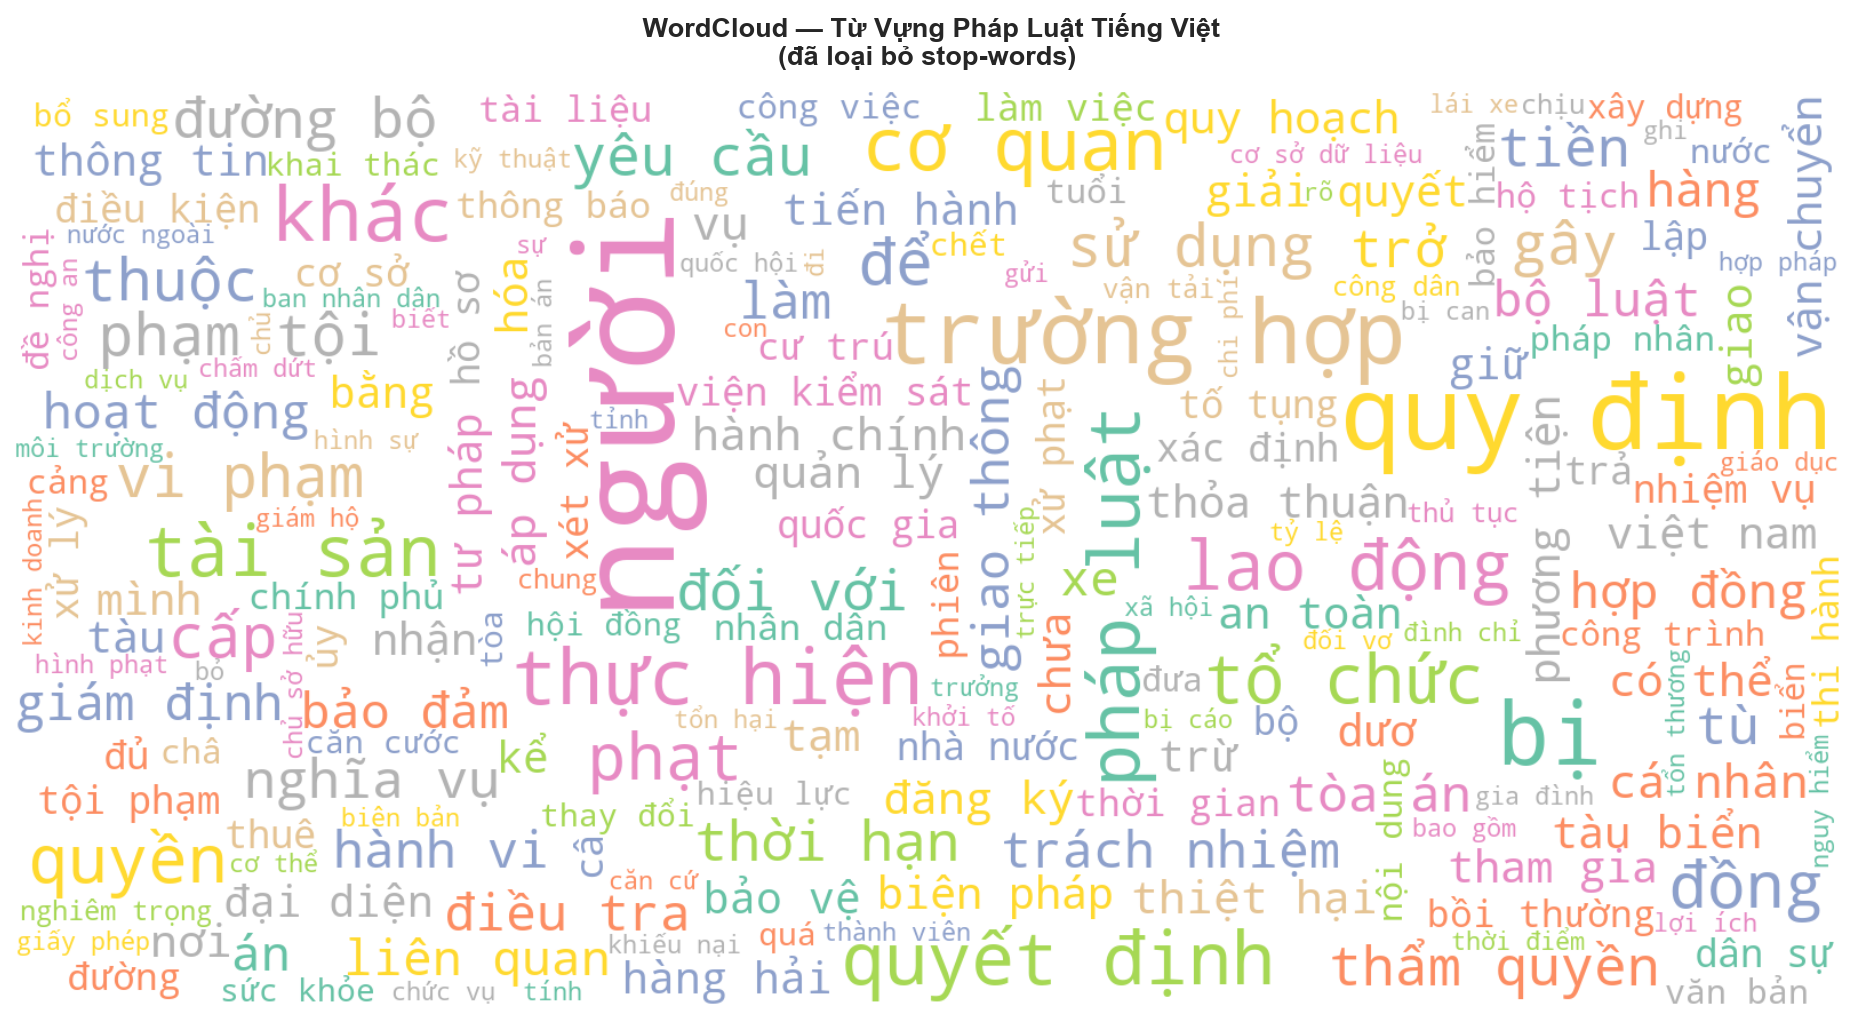

 Đã lưu: wordcloud_phapluat.png


In [19]:
token_freq = Counter(all_tokens)
print(f' Số từ duy nhất: {len(token_freq):,}')

fig, ax = plt.subplots(figsize=(16, 8))

try:
    wc = WordCloud(
        width=1600, height=800,
        background_color='white',
        colormap='Set2',
        max_words=200,
        prefer_horizontal=0.85,
        collocations=False,
        min_font_size=10,
        max_font_size=120,
    ).generate_from_frequencies(token_freq)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(' WordCloud — Từ Vựng Pháp Luật Tiếng Việt\n(đã loại bỏ stop-words)',
                 fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    # plt.savefig('wordcloud_phapluat.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(' Đã lưu: wordcloud_phapluat.png')
except Exception as e:
    print(f'  Lỗi WordCloud: {e}\n  → Thử cài font hỗ trợ tiếng Việt và truyền font_path vào WordCloud()')

### 5.3 Top 20 Unigrams (Từ Đơn)

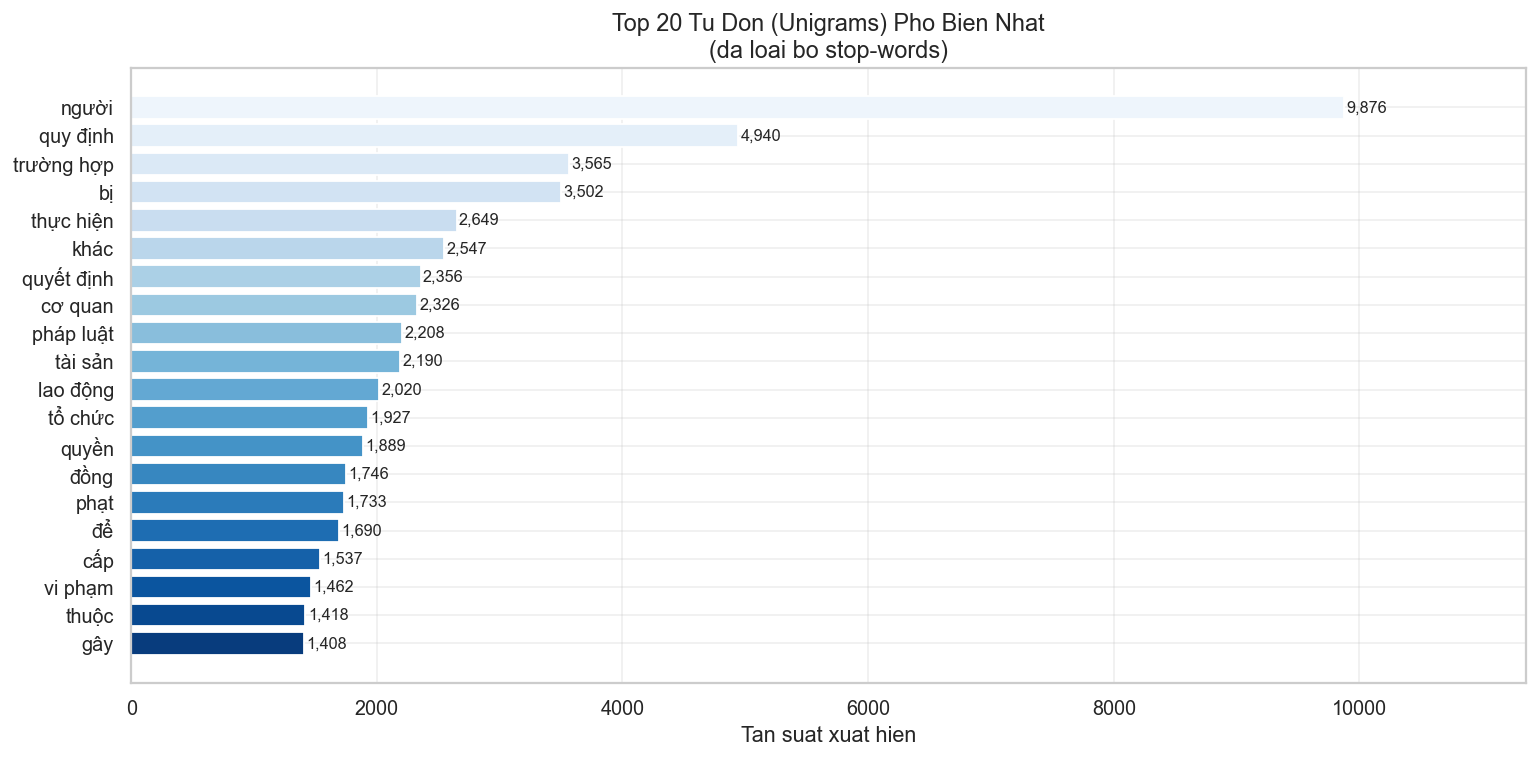

,Tu,Tan suat
0,người,9876
1,quy định,4940
2,trường hợp,3565
3,bị,3502
4,thực hiện,2649
5,khác,2547
6,quyết định,2356
7,cơ quan,2326
8,pháp luật,2208
9,tài sản,2190


In [20]:
top_unigrams = pd.DataFrame(token_freq.most_common(20), columns=['Tu', 'Tan suat'])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_unigrams['Tu'][::-1], top_unigrams['Tan suat'][::-1],
               color=sns.color_palette('Blues_r', 20), edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
ax.set_xlabel('Tan suat xuat hien')
ax.set_title('Top 20 Tu Don (Unigrams) Pho Bien Nhat\n(da loai bo stop-words)', fontsize=13)
ax.margins(x=0.15)
plt.tight_layout()
# plt.savefig('top20_unigrams.png', bbox_inches='tight')
plt.show()

display(top_unigrams)

### 5.4 Top 20 Bigrams & Trigrams (Cụm Thuật Ngữ Pháp Lý)

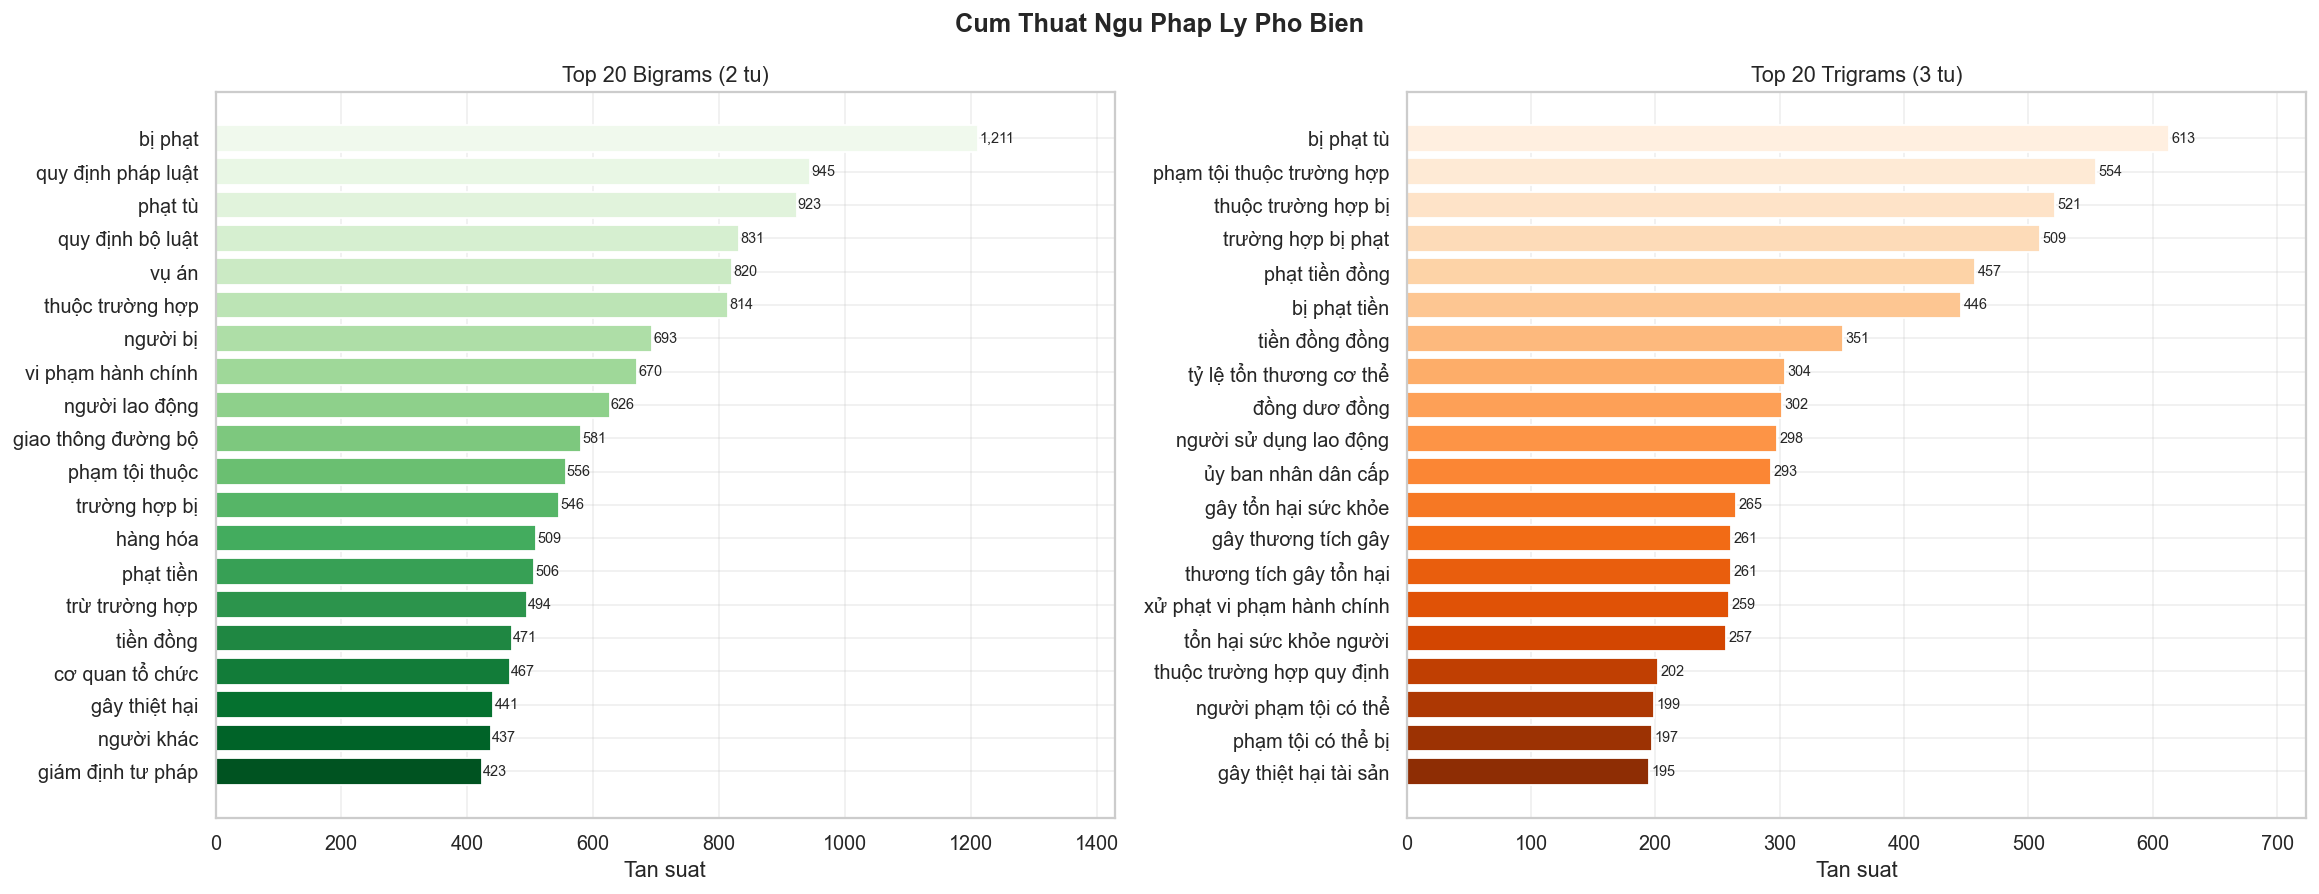

In [21]:
def get_ngrams(token_list, n):
    """Sinh n-grams tu danh sach token."""
    return [' '.join(token_list[i:i+n]) for i in range(len(token_list)-n+1)]

all_bigrams  = list(chain.from_iterable(get_ngrams(t, 2) for t in df_sample['tokens']))
all_trigrams = list(chain.from_iterable(get_ngrams(t, 3) for t in df_sample['tokens']))

top_bigrams  = pd.DataFrame(Counter(all_bigrams).most_common(20),  columns=['Cum tu', 'Tan suat'])
top_trigrams = pd.DataFrame(Counter(all_trigrams).most_common(20), columns=['Cum tu', 'Tan suat'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Cum Thuat Ngu Phap Ly Pho Bien', fontsize=14, fontweight='bold')

for ax, data, title, palette in [
    (axes[0], top_bigrams,  'Top 20 Bigrams (2 tu)', 'Greens_r'),
    (axes[1], top_trigrams, 'Top 20 Trigrams (3 tu)', 'Oranges_r'),
]:
    colors = sns.color_palette(palette, 20)
    bars = ax.barh(data['Cum tu'][::-1], data['Tan suat'][::-1],
                   color=colors, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
    ax.set_xlabel('Tan suat')
    ax.set_title(title, fontsize=12)
    ax.margins(x=0.18)

plt.tight_layout()
# plt.savefig('ngrams_analysis.png', bbox_inches='tight')
plt.show()

In [22]:
print('\nTOP 20 BIGRAMS')
display(top_bigrams)

print('\nTOP 20 TRIGRAMS')
display(top_trigrams)


TOP 20 BIGRAMS


,Cum tu,Tan suat
0,bị phạt,1211
1,quy định pháp luật,945
2,phạt tù,923
3,quy định bộ luật,831
4,vụ án,820
5,thuộc trường hợp,814
6,người bị,693
7,vi phạm hành chính,670
8,người lao động,626
9,giao thông đường bộ,581



TOP 20 TRIGRAMS


,Cum tu,Tan suat
0,bị phạt tù,613
1,phạm tội thuộc trường hợp,554
2,thuộc trường hợp bị,521
3,trường hợp bị phạt,509
4,phạt tiền đồng,457
5,bị phạt tiền,446
6,tiền đồng đồng,351
7,tỷ lệ tổn thương cơ thể,304
8,đồng dươ đồng,302
9,người sử dụng lao động,298


### 5.5 Phân Tích Tags & Cross-references

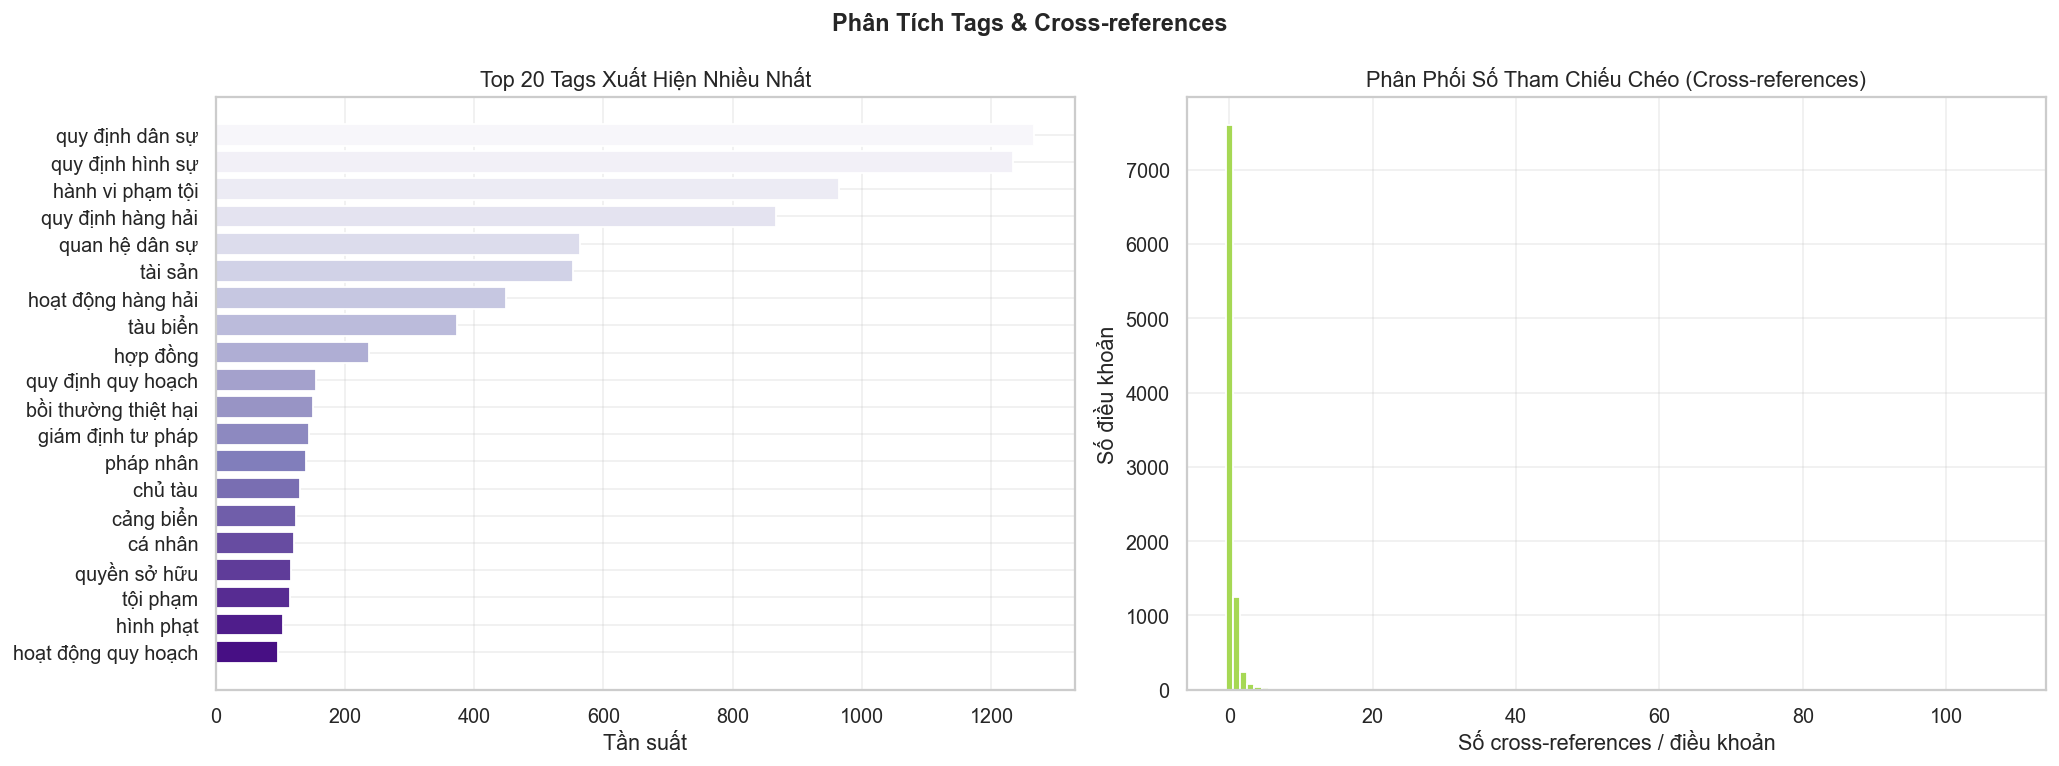

 Đã lưu: tags_crossrefs.png

 Tổng tags: 19,308 | Unique: 5,968
 Điều khoản có cross-reference: 1661 (17.9%)


In [23]:
# Thống kê tags phổ biến
all_tags = list(chain.from_iterable(df_clauses['tags']))
top_tags = pd.DataFrame(Counter(all_tags).most_common(20), columns=['Tag', 'Tần suất'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân Tích Tags & Cross-references', fontsize=13, fontweight='bold')

# Top tags
ax = axes[0]
ax.barh(top_tags['Tag'][::-1], top_tags['Tần suất'][::-1],
        color=sns.color_palette('Purples_r', 20), edgecolor='white')
ax.set_xlabel('Tần suất')
ax.set_title('Top 20 Tags Xuất Hiện Nhiều Nhất')

# Phân phối số cross-references
ax = axes[1]
ax.hist(df_clauses['n_refs'], bins=range(0, df_clauses['n_refs'].max()+2),
        color=PALETTE[4], edgecolor='white', align='left')
ax.set_xlabel('Số cross-references / điều khoản')
ax.set_ylabel('Số điều khoản')
ax.set_title('Phân Phối Số Tham Chiếu Chéo (Cross-references)')

plt.tight_layout()
# plt.savefig('tags_crossrefs.png', bbox_inches='tight')
plt.show()
print(' Đã lưu: tags_crossrefs.png')

print(f"\n Tổng tags: {len(all_tags):,} | Unique: {len(set(all_tags)):,}")
print(f" Điều khoản có cross-reference: {(df_clauses['n_refs'] > 0).sum()} "
      f"({(df_clauses['n_refs'] > 0).mean()*100:.1f}%)")

---
## 6.  Kết Luận & Nhận Xét (Summary)

### 6.1 Tổng Quan Tập Dữ Liệu

In [24]:
print('=' * 65)
print('           KET LUAN EDA — DU LIEU PHAP LUAT TIENG VIET')
print('=' * 65)

empty_rate   = df_clauses['is_empty'].mean() * 100
median_words = df_clauses['word_count'].median()
mean_words   = df_clauses['word_count'].mean()
p95_words    = np.percentile(df_clauses['word_count'], 95)
noise_found  = any(noise_df[c].sum() > 0 for c in noise_cols)

print(f"""
QUY MO TAP DU LIEU:
  Tong so bo luat    : {len(df_laws)}
  Tong so dieu khoan : {len(df_clauses):,}
  Bo luat lon nhat   : {df_laws.loc[df_laws['total_clauses'].idxmax(), 'law_name']} ({df_laws['total_clauses'].max():,} dieu khoan)
  Bo luat nho nhat   : {df_laws.loc[df_laws['total_clauses'].idxmin(), 'law_name']} ({df_laws['total_clauses'].min():,} dieu khoan)

DO DAI DIEU KHOAN:
  Trung binh (mean)  : {mean_words:.0f} tu / dieu khoan
  Trung vi (median)  : {median_words:.0f} tu / dieu khoan
  P95                : {p95_words:.0f} tu
  De xuat chunk_size : ~{int(p95_words * 1.2)} tu (hoac ~{int(p95_words * 6)} ky tu)

CHAT LUONG DU LIEU:
  Ty le content rong : {empty_rate:.2f}%  {'=> Tot' if empty_rate < 1 else '=> Can xu ly'}
  Phat hien nhieu    : {'Co, can lam sach' if noise_found else 'Khong phat hien nhieu dang ke'}

NLP / THUAT NGU PHAP LY:
  Tu pho bien nhat   : {top_unigrams.iloc[0]['Tu']} ({top_unigrams.iloc[0]['Tan suat']:,} lan)
  Bigram pho bien    : {top_bigrams.iloc[0]['Cum tu']} ({top_bigrams.iloc[0]['Tan suat']:,} lan)
  Trigram pho bien   : {top_trigrams.iloc[0]['Cum tu']} ({top_trigrams.iloc[0]['Tan suat']:,} lan)
""")
print('=' * 65)

           KET LUAN EDA — DU LIEU PHAP LUAT TIENG VIET

QUY MO TAP DU LIEU:
  Tong so bo luat    : 17
  Tong so dieu khoan : 9,259
  Bo luat lon nhat   : Bộ luật Dân sự 2015 (1,635 dieu khoan)
  Bo luat nho nhat   : Luật Phòng, chống tác hại của rượu, bia 2019 (147 dieu khoan)

DO DAI DIEU KHOAN:
  Trung binh (mean)  : 63 tu / dieu khoan
  Trung vi (median)  : 47 tu / dieu khoan
  P95                : 171 tu
  De xuat chunk_size : ~205 tu (hoac ~1026 ky tu)

CHAT LUONG DU LIEU:
  Ty le content rong : 0.00%  => Tot
  Phat hien nhieu    : Co, can lam sach

NLP / THUAT NGU PHAP LY:
  Tu pho bien nhat   : người (9,876 lan)
  Bigram pho bien    : bị phạt (1,211 lan)
  Trigram pho bien   : bị phạt tù (613 lan)



### 6.2 Nhận Xét Chi Tiết & Khuyến Nghị

####  Điểm Mạnh Của Tập Dữ Liệu
1. **Cấu trúc nhất quán**: Tất cả file JSON tuân theo schema thống nhất (`law_info` + `clauses`), thuận lợi cho việc xây dựng pipeline tự động.
2. **Metadata đầy đủ**: Mỗi điều khoản đều có `position` (chapter/article/clause), `tags` phân loại chủ đề và `cross_references` cho phép xây dựng knowledge graph.
3. **Nội dung phong phú**: Phủ nhiều lĩnh vực pháp luật (dân sự, doanh nghiệp, gia đình, tòa án).

####  Vấn Đề Cần Xử Lý Trước Khi Đưa Vào Mô Hình AI
1. **Độ dài không đồng đều** (imbalanced length): Phân phối right-skewed — một số điều khoản rất ngắn (có thể là tên chương/phần mục không có nội dung thực) và một số rất dài. Nên lọc bỏ các điều khoản có `word_count < 5` và chunking các điều khoản vượt quá ngưỡng.
2. **Stop-words pháp luật**: Các từ như `điều`, `khoản`, `điểm`, `luật` xuất hiện quá nhiều nhưng ít mang ý nghĩa phân biệt. Cần bổ sung vào danh sách stop-words tùy theo task.
3. **Encoding tiếng Việt**: Nếu hệ thống không hỗ trợ Unicode tốt, cần normalize về NFC trước khi xử lý.

####  Khuyến Nghị Kỹ Thuật
| Tác vụ | Khuyến nghị |
|--------|-------------|
| **Chunking cho RAG** | `chunk_size` ≈ P95 word_count × 1.2; `overlap` = 20% chunk_size |
| **Embedding** | Dùng `PhoBERT` hoặc `bge-m3` hỗ trợ tiếng Việt |
| **Làm sạch** | Lọc `word_count < 5`, normalize Unicode, loại bỏ ký tự đặc biệt |
| **Metadata filtering** | Tận dụng `law_id`, `chapter`, `article` cho metadata filter trong vector DB |
| **Cross-reference** | Xây knowledge graph từ `cross_references` để tăng độ chính xác retrieval |

In [25]:
# Export báo cáo tổng hợp ra CSV
df_laws.to_csv('report_laws_summary.csv', index=False, encoding='utf-8-sig')
df_clauses[['clause_id','law_id','chapter','article','article_title',
             'word_count','char_count','is_empty','n_tags','n_refs']].to_csv(
    'report_clauses_stats.csv', index=False, encoding='utf-8-sig')

print(' Đã xuất báo cáo:')
print('    report_laws_summary.csv')
print('    report_clauses_stats.csv')
print('\n EDA hoàn thành!')

 Đã xuất báo cáo:
    report_laws_summary.csv
    report_clauses_stats.csv

 EDA hoàn thành!
